Running in Jupyter Notebook or interactive console. Using Path.cwd() for project_dir.
Project directory: C:\Users\hidbe\PycharmProjects\MOGRN
src directory C:\Users\hidbe\PycharmProjects\MOGRN\src added to sys.path if not already there.
[INFO] Successfully imported LYR processing utilities
Project directory: C:\Users\hidbe\PycharmProjects\MOGRN
Output directory: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output
Cache directory: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache
GRN tables directory: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_grn_tables
Cache file not found: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\raw_structures_A.pkl
Loading processed structures from cache: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\processed_structures_A.pkl
Successfully loaded processed structures
Loading structure errors from cache: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\structure_errors_A.pkl
Successfully loaded structure errors
Loading helix annot

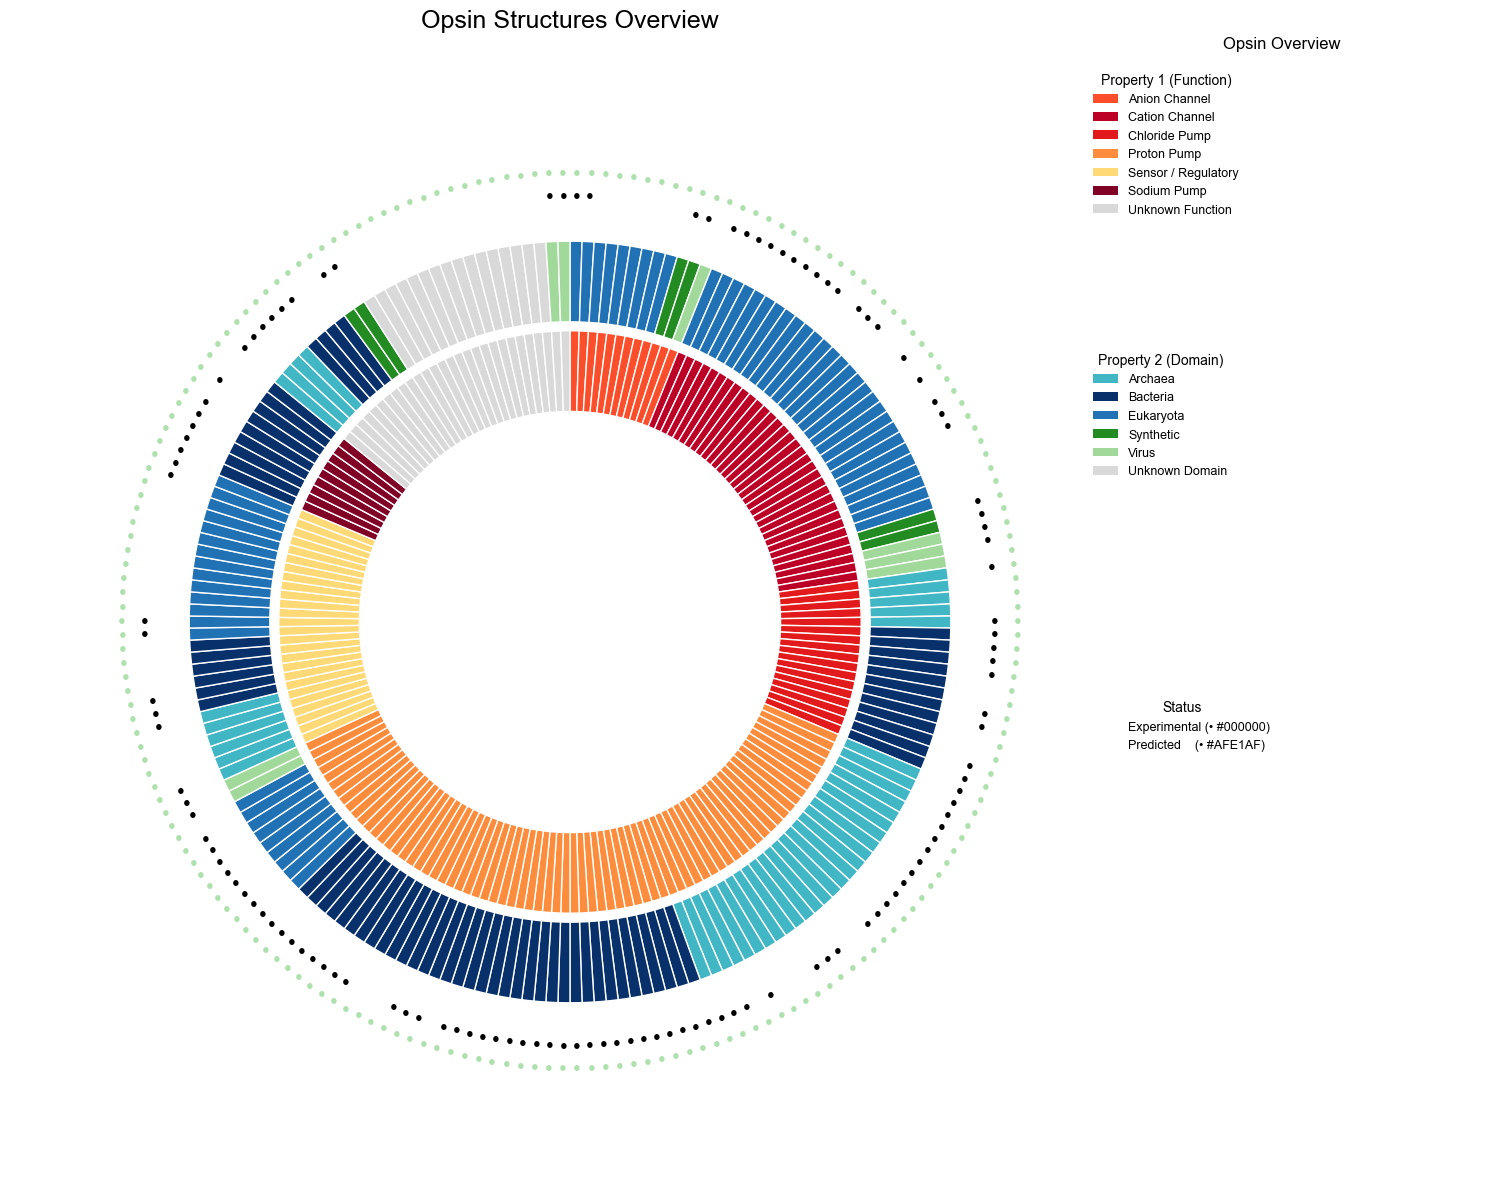

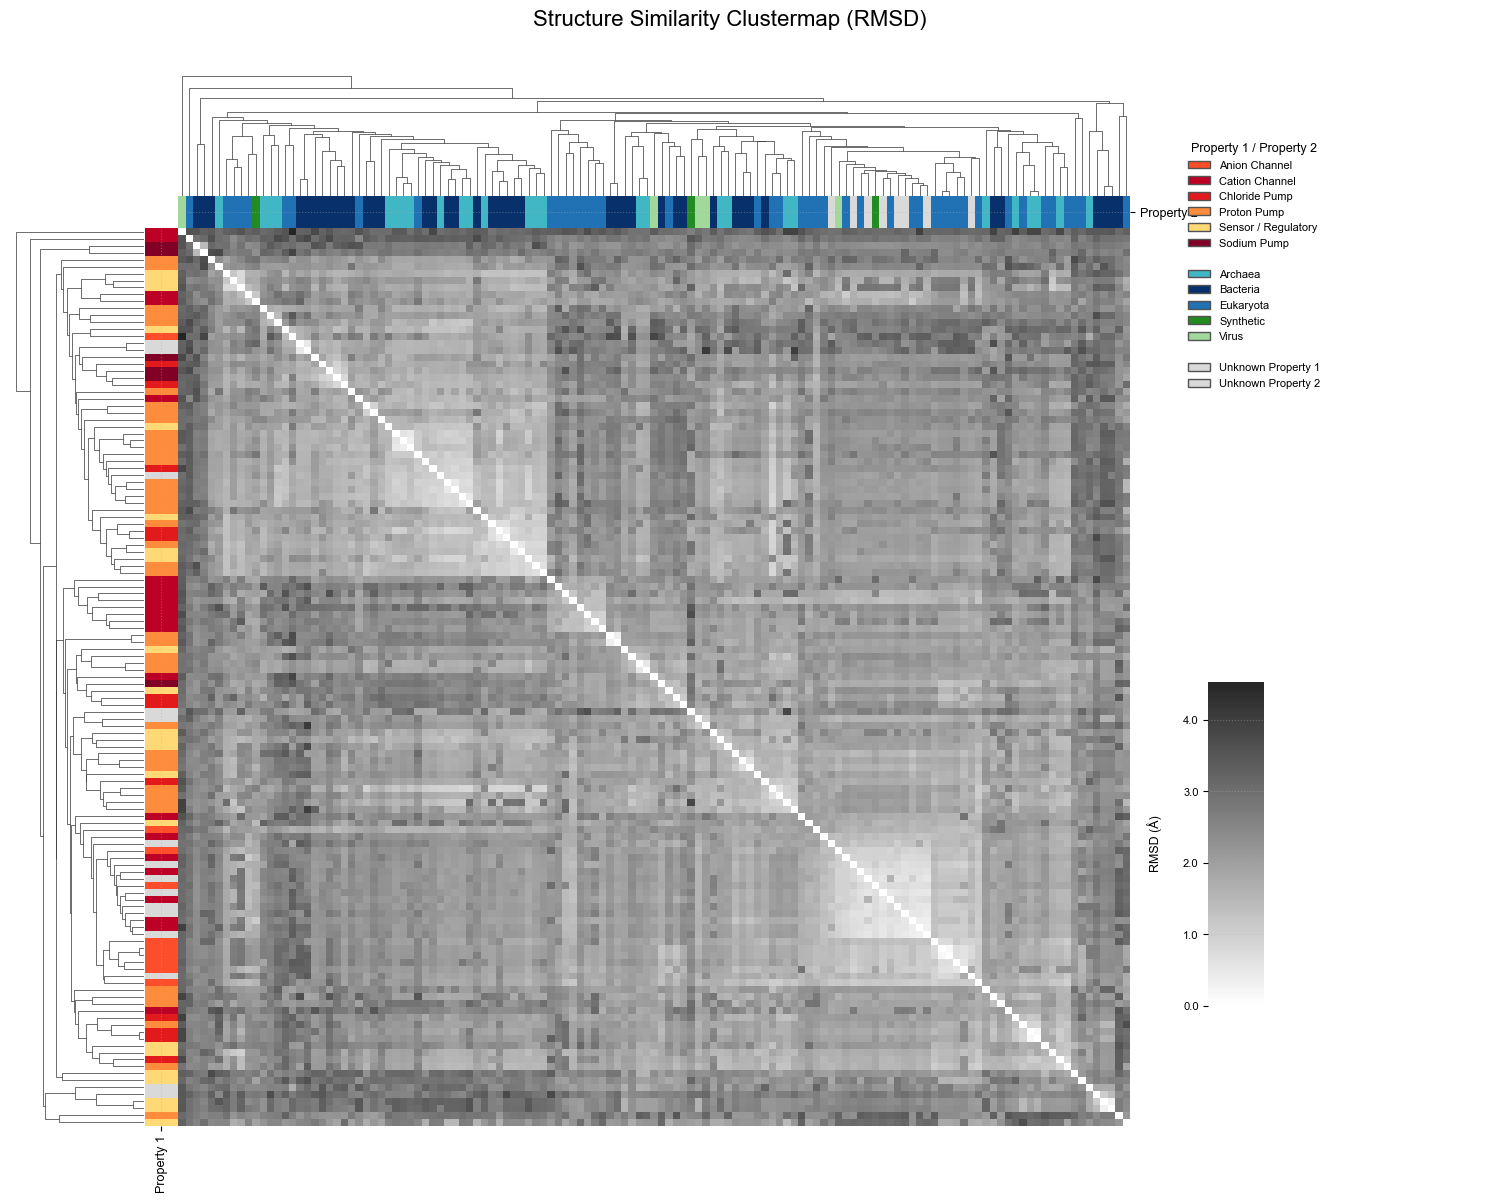

Filtered out 32 columns with less than 2 non-NaN entries.


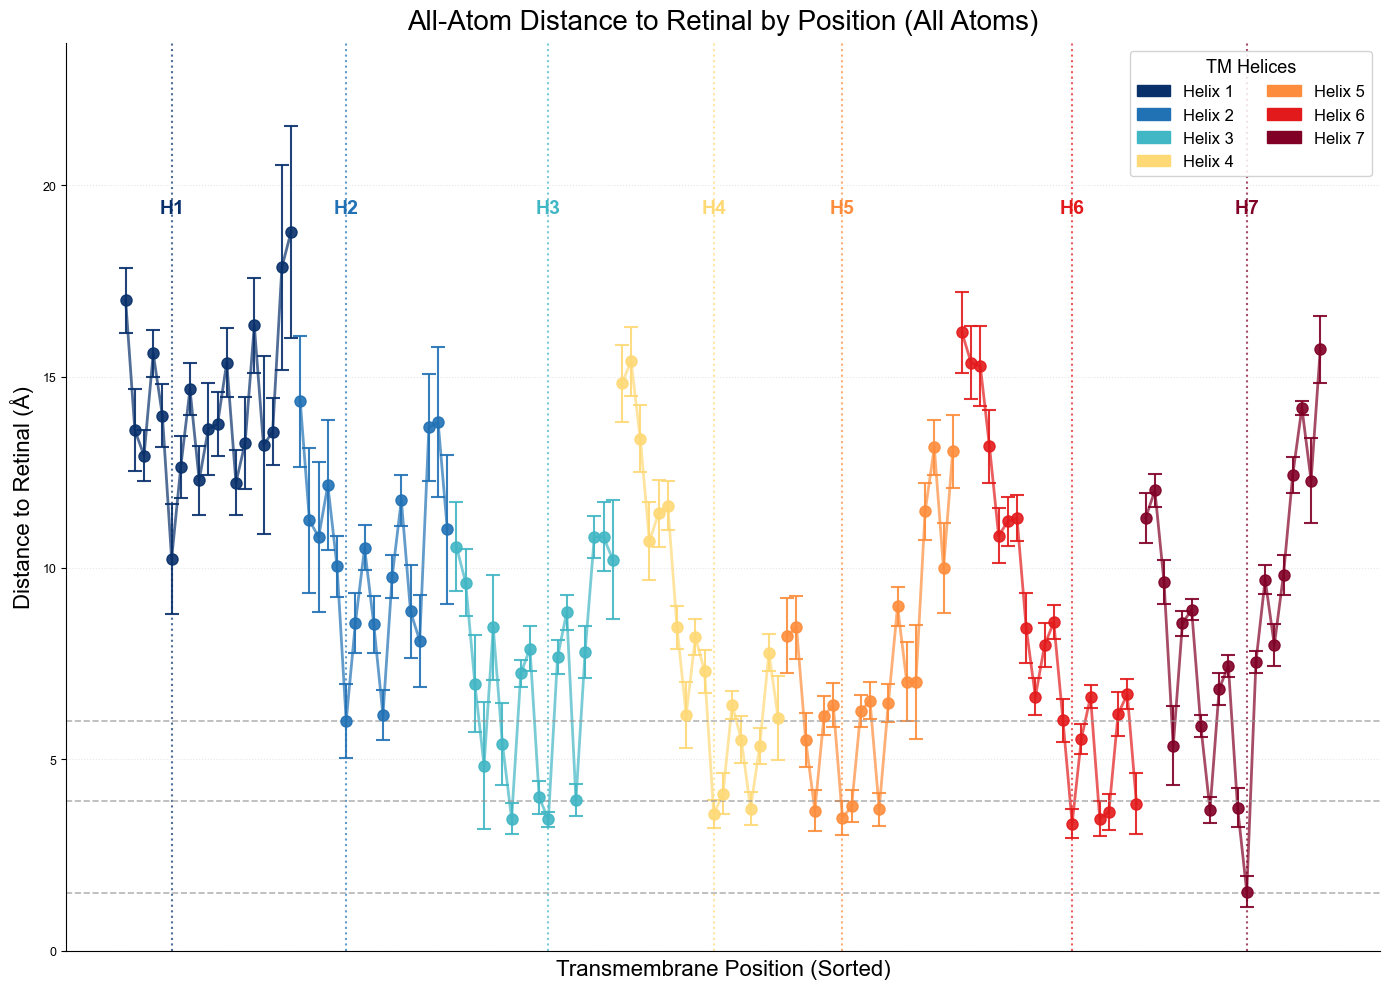

Filtered out 130 columns with less than 2 non-NaN entries.


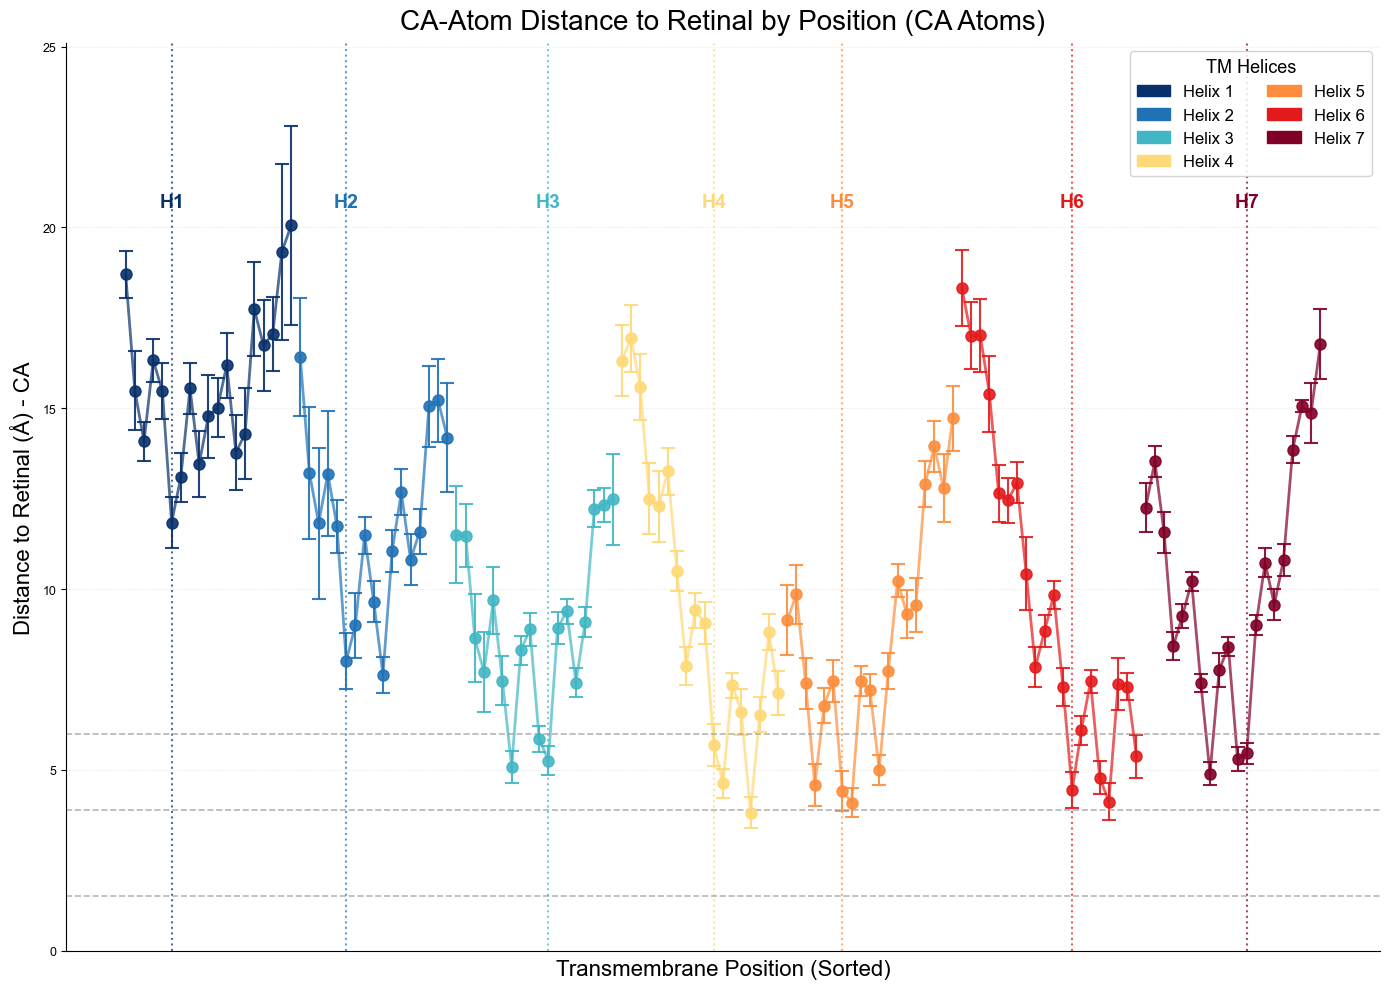

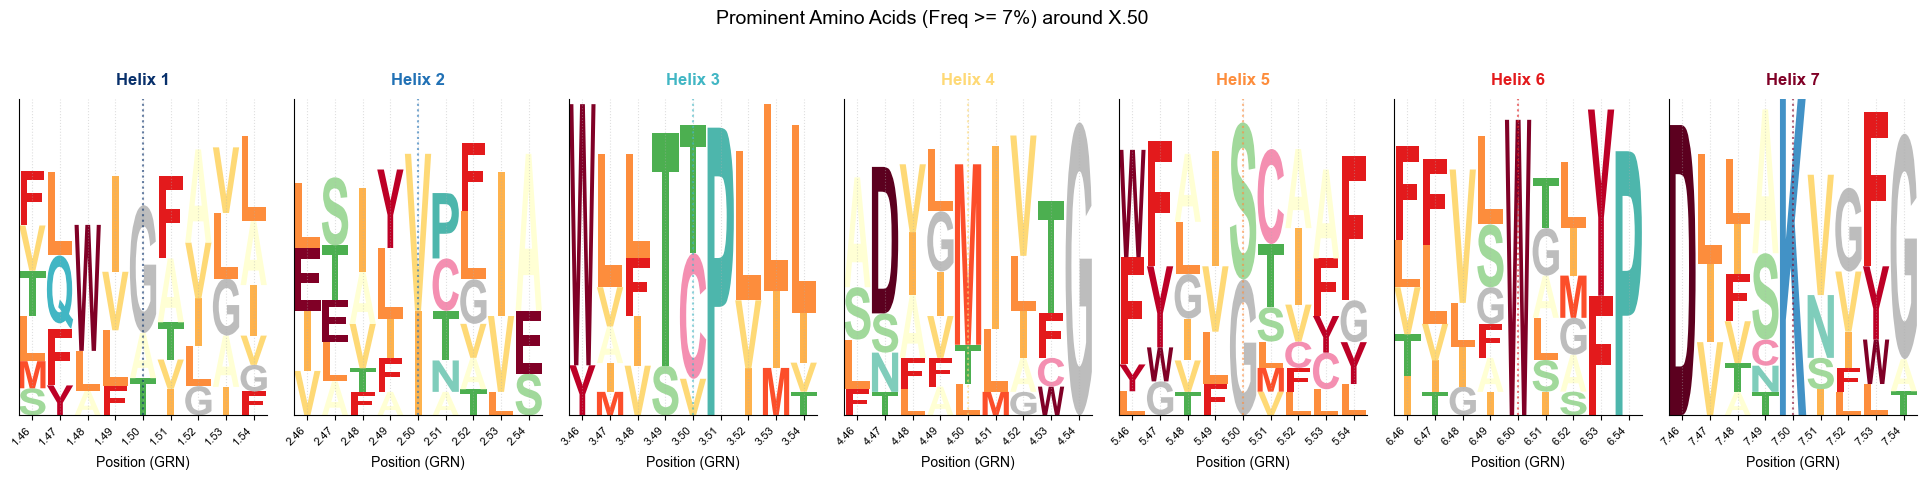

In [1]:
# Load Data for Analysis
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import traceback
import json
from pathlib import Path
import traceback

import os
import sys
from pathlib import Path

# In a Jupyter Notebook, __file__ is not defined.
# Use os.getcwd() or Path.cwd() to get the current working directory,
# which is often the project root when running notebooks.
try:
    # This will work if running as a .py script
    current_file_path = Path(__file__).resolve()
    project_dir = current_file_path.parent
except NameError:
    # This will work in a Jupyter Notebook
    print("Running in Jupyter Notebook or interactive console. Using Path.cwd() for project_dir.")
    project_dir = Path.cwd() # Or Path('.').resolve()

print(f"Project directory: {project_dir}")

src_dir = project_dir / 'src'
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))
print(f"src directory {src_dir} added to sys.path if not already there.")

from src.data_processing import load_opsin_property_data

# Set project directories
project_dir = os.path.dirname(os.path.abspath('__file__'))
output_dir = os.path.join(project_dir, 'opsin_output')
cache_dir = os.path.join(output_dir, 'cache')
grn_tables_dir = os.path.join(project_dir, 'opsin_grn_tables')

print(f"Project directory: {project_dir}")
print(f"Output directory: {output_dir}")
print(f"Cache directory: {cache_dir}")
print(f"GRN tables directory: {grn_tables_dir}")

# Initialize data dictionary
data = {}  # This will hold all our analysis data

# Function to load cached data
def load_cached_data(cache_path, description="data"):
    """Load cached data from pickle file"""
    try:
        if os.path.exists(cache_path):
            print(f"Loading {description} from cache: {cache_path}")
            with open(cache_path, 'rb') as f:
                result = pickle.load(f)
                print(f"Successfully loaded {description}")
                return result
        else:
            print(f"Cache file not found: {cache_path}")
            return None
    except Exception as e:
        print(f"Error loading {description} from cache: {e}")
        traceback.print_exc()
        return None

# Load GRN tables data if available
def load_grn_tables_data():
    grn_tables_pkl = os.path.join(grn_tables_dir, 'grn_tables_data.pkl')
    if os.path.exists(grn_tables_pkl):
        try:
            with open(grn_tables_pkl, 'rb') as f:
                grn_data = pickle.load(f)
                print(f"Successfully loaded GRN tables data")
                return grn_data
        except Exception as e:
            print(f"Error loading GRN tables data: {e}")
            traceback.print_exc()
    else:
        print(f"GRN tables data file not found: {grn_tables_pkl}")
    return None

# Load main workflow data
chain_id = 'A'

# Try to load all cached data from the workflow
cache_files = {
    "raw_structures": (f"raw_structures_{chain_id}.pkl", "raw structures"),
    "processed_structures": (f"processed_structures_{chain_id}.pkl", "processed structures"),
    "structure_errors": (f"structure_errors_{chain_id}.pkl", "structure errors"),
    "helix_annotations": (f"helix_annotations_{chain_id}.pkl", "helix annotations"),
    "structure_comparison": (f"structure_comparison_{chain_id}.pkl", "structure comparison"),
    "grn_assignment": (f"grn_assignment_{chain_id}.pkl", "GRN assignment")
}

for data_type, (file_name, description) in cache_files.items():
    cache_path = os.path.join(cache_dir, file_name)
    component_data = load_cached_data(cache_path, description)
    if component_data:
        # If the component data is a dictionary, update the main data dictionary
        if isinstance(component_data, dict):
            data.update(component_data)
        # Otherwise store it directly
        else:
            data[data_type] = component_data

# Additionally, load the GRN tables data
grn_data = load_grn_tables_data()
if grn_data:
    data.update(grn_data)
    
# Print confirmation of data loading
print(f"\nLoaded data with {len(data.keys())} top-level keys")
if 'processed_structures' in data:
    print(f"Found {len(data['processed_structures'])} processed structures")

# Load property data with correct function
property_data = load_opsin_property_data('property/mo_exp.csv', data['processed_structures'])
data['property_data'] = property_data['properties']
data['property_data'] = {
    k.replace('_smile_', '_'): v
    for k, v in data['property_data'].items()
}
data['structure_mapping'] = property_data['structure_mapping']


property_data.keys()

# In your plotting scripts (e.g., visualizations.py)

# --- Core Color Access & Categorical Color Generation ---
from src.opsin_color_scheme import (
    OPSIN_COLORS,              # For direct access to specific hex codes (e.g., 'black', 'utility_pink')
    get_categorical_colors,    # Replaces old get_group_colors. Use with property_type='property1' or 'property2'
    
    # --- Specific Predefined Categorical Maps (if direct access is preferred over get_categorical_colors) ---
    PROPERTY1_COLORS_PREDEFINED, # Predefined map for molecular function (warm colors)
    PROPERTY2_COLORS_PREDEFINED, # Predefined map for domain (cold colors)
    HELIX_STRING_COLORS,       # Or HELIX_NUMBER_COLORS, depending on your data type for helices
    HELIX_NUMBER_COLORS,
    AMINO_ACID_LOGO_COLORS,    # For sequence logo plots
    STATUS_EXPERIMENTAL_COLOR, # Specific color for experimental status
    STATUS_PREDICTED_COLOR,    # Specific color for predicted status

    # --- Colormaps (primarily for continuous data or specific viz like heatmaps) ---
    # For RMSD Heatmap Cells (Grayscale is recommended)
    RMSD_GRAYSCALE_COMPACT_CMAP, # Binned grayscale RMSD map (use by name 'opsin_rmsd_gray_compact' or direct object)
    RMSD_BOUNDS,
    RMSD_GRAYSCALE_CMAP,       # Continuous grayscale RMSD map (use by name 'opsin_rmsd_gray' or direct object)
)



# Import visualization functions
from src.visualization_functions import (
    create_opsin_overview_plot,
    create_and_visualize_similarity_tree,
    visualize_rmsd_matrix_improved,
    plot_similarity_tree,
    plot_rmsd_heatmap,
    plot_distances_with_std,
    plot_helix_logo_plots
)


from protos.processing.grn.grn_utils import sort_grns_str, get_tm_residues





# Visualization 1: Opsins Overview Plot

# First, prepare overview data
overview_data_list = []
processed_structures_map = data.get('processed_structures', {})
property_data_map = data.get('property_data', {})

for sid, struct_info in processed_structures_map.items():
    if sid in property_data_map.keys():
        # print(sid)
        pass
    else:
        print(sid)
    mf, domain, is_experimental, display_name = "Unknown", "Unknown", False, sid
    
    # Try to get properties from property_data_map
    prop_entry = property_data_map.get(sid)
    
    if prop_entry and isinstance(prop_entry, dict):
        mf_val = prop_entry.get('molecular_function')
        if pd.notna(mf_val) and str(mf_val).strip() and str(mf_val).lower() != "unknown": 
            mf = str(mf_val)
            
        domain_val = prop_entry.get('domain')
        if pd.notna(domain_val) and str(domain_val).strip() and str(domain_val).lower() != "unknown": 
            domain = str(domain_val)
            
        is_experimental_prop = prop_entry.get('experimentally_determined', False)
        if isinstance(is_experimental_prop, str):
            is_experimental = is_experimental_prop.lower() == 'true'
        elif isinstance(is_experimental_prop, bool):
            is_experimental = is_experimental_prop
            
        display_name_prop = prop_entry.get('short_name', prop_entry.get('display_name'))
        if pd.notna(display_name_prop) and str(display_name_prop).strip(): 
            display_name = str(display_name_prop)
    
    # Fallback to structure info if needed
    if isinstance(struct_info, dict):
        struct_props = struct_info.get('properties', {})
        if isinstance(struct_props, dict):
            if mf == "Unknown":
                mf_val_struct = struct_props.get('molecular_function')
                if pd.notna(mf_val_struct) and str(mf_val_struct).strip() and str(mf_val_struct).lower() != "unknown": 
                    mf = str(mf_val_struct)
                    
            if domain == "Unknown":
                domain_val_struct = struct_props.get('domain')
                if pd.notna(domain_val_struct) and str(domain_val_struct).strip() and str(domain_val_struct).lower() != "unknown": 
                    domain = str(domain_val_struct)
    
    overview_data_list.append({
        'id': sid,
        'short_name': display_name, 
        'molecular_function_normalized': mf,
        'domain': domain, 
        'experimentally_determined': is_experimental
    })

overview_df = pd.DataFrame(overview_data_list)
flat_list = []
for k, v in data['structure_mapping'].items():
    flat_list.append(k)
    flat_list.append(v)




overview_df['experimentally_determined'] = overview_df['id'].isin(flat_list)


# Create overview plot
fig_overview = create_opsin_overview_plot(overview_df)
plt.title("Opsin Overview")
plt.show()





overview_df['molecular_function_normalized'].unique()

overview_df['domain'].unique()

# Create a group dictionary mapping structure IDs to molecular functions
group_dict = {}
domain_dict = {}

for item in overview_data_list:
    group_dict[item['id']] = item['molecular_function_normalized']
    domain_dict[item['id']] = {'domain': item['domain'], 'average_error': None}

# Get RMSD matrix from data
if 'rmsd_matrix' in data and isinstance(data['rmsd_matrix'], pd.DataFrame):
    rmsd_df = data['rmsd_matrix']
elif 'rmsd_df' in data and isinstance(data['rmsd_df'], pd.DataFrame):
    rmsd_df = data['rmsd_df']
else:
    print("RMSD matrix not found in data")
    rmsd_df = pd.DataFrame()



RMSD_BOUNDS

# Visualization 3: RMSD Heatmap with Improved Visualization

if not rmsd_df.empty:
    # First we need to create a linkage matrix for hierarchical clustering
    from scipy.spatial.distance import squareform
    from scipy.cluster.hierarchy import linkage
    
    # Convert the RMSD matrix to a condensed distance matrix
    # Fill NA values with a large number
    rmsd_matrix_for_linkage = rmsd_df.copy()
    # Convert to condensed form and create linkage matrix
    condensed_matrix = squareform(rmsd_matrix_for_linkage.values, checks=False)
    Z_linkage = linkage(condensed_matrix, method='average')
    
    # Create improved RMSD heatmap with clustering and annotations
    # Use group_dict for molecular function (warm colors) and domain_dict for domain (cold colors)
    # RMSD values will use the grayscale colormap
    fig_heatmap = visualize_rmsd_matrix_improved(
        rmsd_df=rmsd_df,
        group_dict=group_dict,      # Molecular function (warm colors)
        domain_dict=domain_dict,    # Domain info (cold colors)
        linkage_matrix=Z_linkage,
        figsize=(16, 12)
    )
    plt.show()












# Check if distance tables are available
distance_table = None
if 'distance_table' in data and isinstance(data['distance_table'], pd.DataFrame):
    distance_table = data['distance_table']


# Check if CA distance table is available
ca_distance_table = None
if 'ca_distance_table' in data and isinstance(data['ca_distance_table'], pd.DataFrame):
    ca_distance_table = data['ca_distance_table']


# Check if residue table or MSA is available for logo plots
residue_table_for_logo = None
if 'msa_df' in data and isinstance(data['msa_df'], pd.DataFrame):
    residue_table_for_logo = data['msa_df']
elif msa_table is not None:
    residue_table_for_logo = msa_table


# --- Your Filtering Logic for residue_table_for_logo ---
col_name = '7.50'

if col_name in residue_table_for_logo.columns:
    # Ensure the column is treated as string, handle NaNs or non-string types gracefully
    # Keep rows where the condition is met (starts with 'K')
    # na=False ensures that NaN values (which become 'nan' after astype(str)) don't match
    boolean_mask = residue_table_for_logo[col_name].astype(str).str.startswith('K', na=False)
    df_filtered_residue = residue_table_for_logo[boolean_mask]

    # --- Filter distance_table to match df_filtered_residue ---
    # Option 1: Using the index of the filtered residue table
    # This is generally the most robust way if indices align.
    df_filtered_distance = distance_table.loc[df_filtered_residue.index]
    df_filtered_ca_distance = ca_distance_table.loc[df_filtered_residue.index]



grns = get_tm_residues(sort_grns_str(df_filtered_distance.columns.tolist()))

df_filtered_residue

OPSIN_COLORS

# Visualization 4: Distance to Retinal Plot


if df_filtered_distance is not None and not df_filtered_distance.empty:
    # Create distance plot
    fig_distance = plot_distances_with_std(df_filtered_distance[grns], 
                                          title="All-Atom Distance to Retinal by Position", 
                                          use_ca=False, figsize=(14, 10))
    plt.show()

# Visualization 5: CA-Atom Distance to Retinal Plot

if df_filtered_ca_distance is not None and not df_filtered_ca_distance.empty:
    # Create CA distance plot
    fig_ca_distance = plot_distances_with_std(df_filtered_ca_distance, 
                                             title="CA-Atom Distance to Retinal by Position", 
                                             use_ca=True, figsize=(14, 10))
    plt.show()





# Visualization 7: Helix Logo Plots
if df_filtered_residue is not None and not df_filtered_residue.empty:
    # Create logo plots
    fig_logo = plot_helix_logo_plots(df_filtered_residue, frequency_threshold=.07)
    plt.show()









